<a href="https://colab.research.google.com/github/SathishKentState/Sathish-Babu-Nuthi_Advanced-Machine-Learning/blob/main/Sathish__Babu__Nuthi__BA74061_Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence

In [36]:
max_features = 10000
maxlen = 150
training_samples = 100
validation_samples = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)

x_train_small = x_train[:training_samples]
y_train_small = y_train[:training_samples]

x_val = x_train[training_samples:training_samples + validation_samples]
y_val = y_train[training_samples:training_samples + validation_samples]

print("x_train_small shape:", x_train_small.shape)
print("x_val shape:", x_val.shape)

x_train_small shape: (100, 150)
x_val shape: (10000, 150)


In [11]:
model_scratch = keras.Sequential([
    layers.Embedding(input_dim=max_features, output_dim=100, input_length=maxlen),
    layers.LSTM(32),
    layers.Dense(1, activation="sigmoid")
])

model_scratch.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_scratch.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
history_scratch = model_scratch.fit(
    x_train_small,
    y_train_small,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val)
)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 919ms/step - accuracy: 0.5700 - loss: 0.6927 - val_accuracy: 0.4969 - val_loss: 0.6932
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 549ms/step - accuracy: 0.5800 - loss: 0.6844 - val_accuracy: 0.4948 - val_loss: 0.6939
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 547ms/step - accuracy: 0.5800 - loss: 0.6756 - val_accuracy: 0.4949 - val_loss: 0.6939
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 520ms/step - accuracy: 0.5800 - loss: 0.6656 - val_accuracy: 0.4949 - val_loss: 0.6946
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 521ms/step - accuracy: 0.5800 - loss: 0.6518 - val_accuracy: 0.4948 - val_loss: 0.7036
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 525ms/step - accuracy: 0.5800 - loss: 0.6318 - val_accuracy: 0.4948 - val_loss: 0.7204
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 871ms/step - accuracy: 0.5800 - loss: 0.6076 - val_accuracy: 0.4948 - val_loss: 0.7296
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 667ms/step - accuracy: 0.6100 - loss: 0.5830 - val_accuracy: 0.4948 - val_loss:

In [13]:
print("Best validation accuracy:", max(history_scratch.history["val_accuracy"]))

Best validation accuracy: 0.5252000093460083


In [37]:
word_index = imdb.get_word_index()

word_index = {word: (index + 3) for word, index in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2
word_index["<UNUSED>"] = 3

print("Number of words in word_index:", len(word_index))
print("Example words:", list(word_index.items())[:10])

Number of words in word_index: 88588
Example words: [('fawn', 34704), ('tsukino', 52009), ('nunnery', 52010), ('sonja', 16819), ('vani', 63954), ('woods', 1411), ('spiders', 16118), ('hanging', 2348), ('woody', 2292), ('trawling', 52011)]


In [15]:
embedding_dim = 100
embeddings_index = {}

glove_path = "glove.6B.100d.txt"

with open(glove_path, encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = coefs

print("Total GloVe word vectors:", len(embeddings_index))

Total GloVe word vectors: 400000


In [38]:
embedding_matrix = np.zeros((max_features, embedding_dim))

for word, i in word_index.items():
    if i < max_features:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

print("Embedding matrix shape:", embedding_matrix.shape)

nonzero_rows = np.sum(np.any(embedding_matrix != 0, axis=1))
print("Words with pretrained vectors:", nonzero_rows)

Embedding matrix shape: (10000, 100)
Words with pretrained vectors: 9793


In [17]:
model_pretrained = keras.Sequential([
    layers.Embedding(
        input_dim=max_features,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        trainable=False
    ),
    layers.LSTM(32),
    layers.Dense(1, activation="sigmoid")
])

model_pretrained.build(input_shape=(None, maxlen))

model_pretrained.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_pretrained.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 150, 100)       │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,017,057 (3.88 MB)

 Trainable params: 17,057 (66.63 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [18]:
history_pretrained = model_pretrained.fit(
    x_train_small,
    y_train_small,
    epochs=10,
    batch_size=32,
    validation_data=(x_val, y_val)
)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 619ms/step - accuracy: 0.5700 - loss: 0.7077 - val_accuracy: 0.4950 - val_loss: 0.7346
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.5800 - loss: 0.6820 - val_accuracy: 0.4982 - val_loss: 0.7031
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 526ms/step - accuracy: 0.5700 - loss: 0.6598 - val_accuracy: 0.4962 - val_loss: 0.7055
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 506ms/step - accuracy: 0.5800 - loss: 0.6503 - val_accuracy: 0.4959 - val_loss: 0.7074
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 549ms/step - accuracy: 0.5900 - loss: 0.6414 - val_accuracy: 0.4954 - val_loss: 0.7213
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 511ms/step - accuracy: 0.5800 - loss: 0.6362 - val_accuracy: 0.5097 - val_loss: 0.7019
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 531ms/step - accuracy: 0.6300 - loss: 0.6210 - val_accuracy: 0.5388 - val_loss: 0.6926
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 962ms/step - accuracy: 0.7300 - loss: 0.6114 - val_accuracy: 0.5009 - val_loss: 0.

In [19]:
print("Best pretrained validation accuracy:", max(history_pretrained.history["val_accuracy"]))

Best pretrained validation accuracy: 0.5593000054359436


In [20]:
print("Best scratch validation accuracy:", max(history_scratch.history["val_accuracy"]))
print("Best pretrained validation accuracy:", max(history_pretrained.history["val_accuracy"]))

Best scratch validation accuracy: 0.5252000093460083
Best pretrained validation accuracy: 0.5593000054359436


In [39]:
def run_models_for_sample_size(sample_size):
    x_train_small = x_train[:sample_size]
    y_train_small = y_train[:sample_size]

    print(f"\n========== SAMPLE SIZE: {sample_size} ==========")


    model_scratch_block = keras.Sequential([
        layers.Embedding(input_dim=max_features, output_dim=100),
        layers.LSTM(32),
        layers.Dense(1, activation="sigmoid")
    ])

    model_scratch_block.build(input_shape=(None, maxlen))

    model_scratch_block.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    print("\nTraining SCRATCH embedding model...\n")
    history_scratch_block = model_scratch_block.fit(
        x_train_small,
        y_train_small,
        epochs=10,
        batch_size=32,
        validation_data=(x_val, y_val),
        verbose=1
    )

    scratch_val_acc = history_scratch_block.history["val_accuracy"]
    scratch_best_epoch = np.argmax(scratch_val_acc) + 1
    scratch_best_val_acc = np.max(scratch_val_acc)

    print("\nScratch model epoch-by-epoch validation accuracy:")
    for i, val in enumerate(scratch_val_acc, start=1):
        print(f"Epoch {i}: val_accuracy = {val:.4f}")

    print(f"\nBest Scratch Epoch: {scratch_best_epoch}")
    print(f"Best Scratch Validation Accuracy: {scratch_best_val_acc:.4f}")


    model_pretrained_block = keras.Sequential([
        layers.Embedding(
            input_dim=max_features,
            output_dim=embedding_dim,
            weights=[embedding_matrix],
            trainable=False
        ),
        layers.LSTM(32),
        layers.Dense(1, activation="sigmoid")
    ])

    model_pretrained_block.build(input_shape=(None, maxlen))

    model_pretrained_block.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    print("\nTraining PRETRAINED embedding model...\n")
    history_pretrained_block = model_pretrained_block.fit(
        x_train_small,
        y_train_small,
        epochs=10,
        batch_size=32,
        validation_data=(x_val, y_val),
        verbose=1
    )

    pretrained_val_acc = history_pretrained_block.history["val_accuracy"]
    pretrained_best_epoch = np.argmax(pretrained_val_acc) + 1
    pretrained_best_val_acc = np.max(pretrained_val_acc)

    print("\nPretrained model epoch-by-epoch validation accuracy:")
    for i, val in enumerate(pretrained_val_acc, start=1):
        print(f"Epoch {i}: val_accuracy = {val:.4f}")

    print(f"\nBest Pretrained Epoch: {pretrained_best_epoch}")
    print(f"Best Pretrained Validation Accuracy: {pretrained_best_val_acc:.4f}")


    epochs_range = range(1, 11)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, scratch_val_acc, marker="o", label="Scratch Embedding")
    plt.plot(epochs_range, pretrained_val_acc, marker="o", label="Pretrained Embedding")
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.title(f"Validation Accuracy by Epoch (Sample Size = {sample_size})")
    plt.legend()
    plt.grid(True)
    plt.show()


    if scratch_best_val_acc > pretrained_best_val_acc:
        print(f"\nWinner at sample size {sample_size}: Scratch Embedding")
    elif pretrained_best_val_acc > scratch_best_val_acc:
        print(f"\nWinner at sample size {sample_size}: Pretrained Embedding")
    else:
        print(f"\nWinner at sample size {sample_size}: Tie")

    return {
        "sample_size": sample_size,
        "scratch_best_epoch": scratch_best_epoch,
        "scratch_best_val_accuracy": scratch_best_val_acc,
        "pretrained_best_epoch": pretrained_best_epoch,
        "pretrained_best_val_accuracy": pretrained_best_val_acc
    }


========== SAMPLE SIZE: 100 ==========

Training SCRATCH embedding model...

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 785ms/step - accuracy: 0.5600 - loss: 0.6901 - val_accuracy: 0.4948 - val_loss: 0.6950
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 741ms/step - accuracy: 0.5800 - loss: 0.6769 - val_accuracy: 0.4948 - val_loss: 0.6948
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 504ms/step - accuracy: 0.5800 - loss: 0.6679 - val_accuracy: 0.4950 - val_loss: 0.6942
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 480ms/step - accuracy: 0.5900 - loss: 0.6575 - val_accuracy: 0.4955 - val_loss: 0.6952
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 483ms/step - accuracy: 0.6400 - loss: 0.6377 - val_accuracy: 0.4949 - val_loss: 0.7022
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 573ms/step - accuracy: 0.6200 - loss: 0.6113 - val_accuracy: 0.4948 - val_loss: 0.7228
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 490ms/step - accuracy: 0.6000 - loss: 0.5799 - val_accuracy: 0.5247 - val_loss: 0.6906
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 4

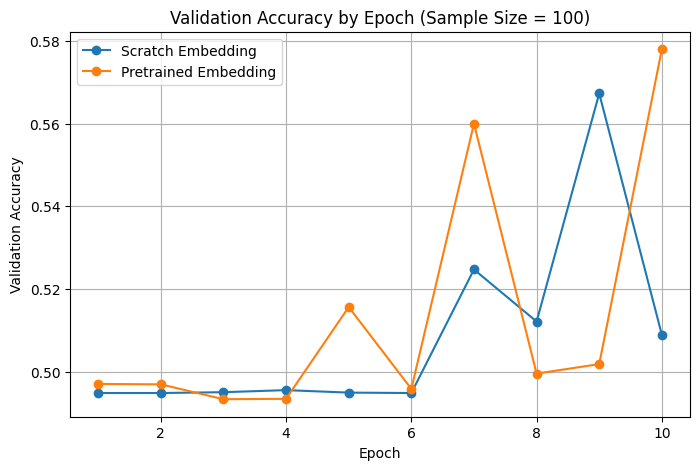


Winner at sample size 100: Pretrained Embedding
{'sample_size': 100, 'scratch_best_epoch': np.int64(9), 'scratch_best_val_accuracy': np.float64(0.567300021648407), 'pretrained_best_epoch': np.int64(10), 'pretrained_best_val_accuracy': np.float64(0.578000009059906)}


In [23]:
result_100 = run_models_for_sample_size(100)
print(result_100)


========== SAMPLE SIZE: 200 ==========

Training SCRATCH embedding model...

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 304ms/step - accuracy: 0.5400 - loss: 0.6894 - val_accuracy: 0.4953 - val_loss: 0.6933
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - accuracy: 0.5750 - loss: 0.6771 - val_accuracy: 0.4956 - val_loss: 0.6937
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - accuracy: 0.5850 - loss: 0.6627 - val_accuracy: 0.4964 - val_loss: 0.6951
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - accuracy: 0.6200 - loss: 0.6437 - val_accuracy: 0.5012 - val_loss: 0.6944
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 308ms/step - accuracy: 0.6950 - loss: 0.6164 - val_accuracy: 0.5114 - val_loss: 0.6951
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 303ms/step - accuracy: 0.7350 - loss: 0.5773 - val_accuracy: 0.5081 - val_loss: 0.7241
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 444ms/step - accuracy: 0.7700 - loss: 0.5211 - val_accuracy: 0.5683 - val_loss: 0.6789
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 2

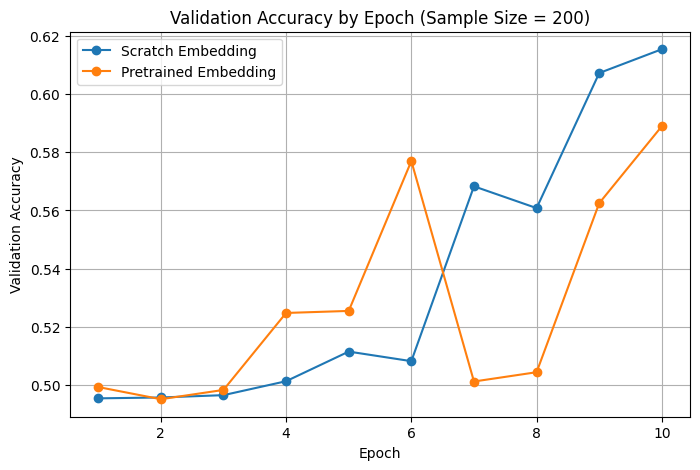


Winner at sample size 200: Scratch Embedding
{'sample_size': 200, 'scratch_best_epoch': np.int64(10), 'scratch_best_val_accuracy': np.float64(0.6154999732971191), 'pretrained_best_epoch': np.int64(10), 'pretrained_best_val_accuracy': np.float64(0.5889999866485596)}


In [24]:
result_200 = run_models_for_sample_size(200)
print(result_200)


========== SAMPLE SIZE: 500 ==========

Training SCRATCH embedding model...

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - accuracy: 0.4740 - loss: 0.6939 - val_accuracy: 0.5424 - val_loss: 0.6919
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.6100 - loss: 0.6889 - val_accuracy: 0.5754 - val_loss: 0.6897
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step - accuracy: 0.7140 - loss: 0.6793 - val_accuracy: 0.6243 - val_loss: 0.6810
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.6900 - loss: 0.6446 - val_accuracy: 0.6605 - val_loss: 0.6351
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - accuracy: 0.7540 - loss: 0.5571 - val_accuracy: 0.6320 - val_loss: 0.6375
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.7860 - loss: 0.4751 - val_accuracy: 0.7269 - val_loss: 0.5608
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 171ms/step - accuracy: 0.8880 - loss: 0.3522 - val_accuracy: 0.7363 - val_loss: 0.5321
Epoch 8/10
16/16 ━━━━━━━━━

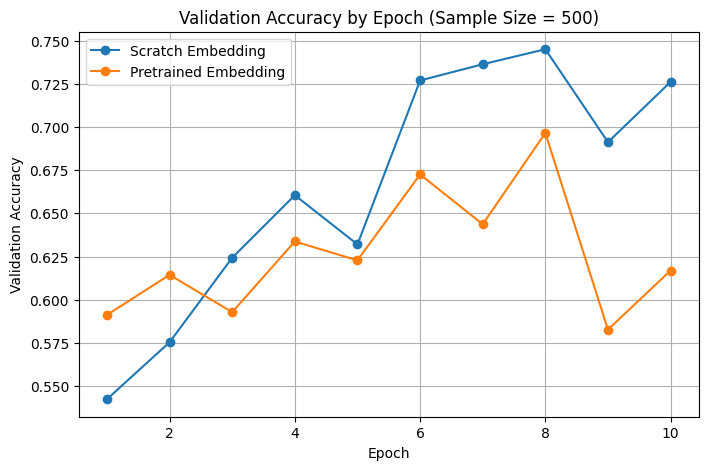


Winner at sample size 500: Scratch Embedding
{'sample_size': 500, 'scratch_best_epoch': np.int64(8), 'scratch_best_val_accuracy': np.float64(0.7450000047683716), 'pretrained_best_epoch': np.int64(8), 'pretrained_best_val_accuracy': np.float64(0.6965000033378601)}


In [25]:
result_500 = run_models_for_sample_size(500)
print(result_500)


========== SAMPLE SIZE: 1000 ==========

Training SCRATCH embedding model...

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.5080 - loss: 0.6919 - val_accuracy: 0.5585 - val_loss: 0.6896
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.6510 - loss: 0.6748 - val_accuracy: 0.6310 - val_loss: 0.6588
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.7020 - loss: 0.5862 - val_accuracy: 0.6971 - val_loss: 0.5826
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.8050 - loss: 0.4521 - val_accuracy: 0.7533 - val_loss: 0.5129
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.8960 - loss: 0.3124 - val_accuracy: 0.7761 - val_loss: 0.4775
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.9250 - loss: 0.2147 - val_accuracy: 0.7838 - val_loss: 0.4922
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.9560 - loss: 0.1389 - val_accuracy: 0.7475 - val_loss: 0.5865
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━

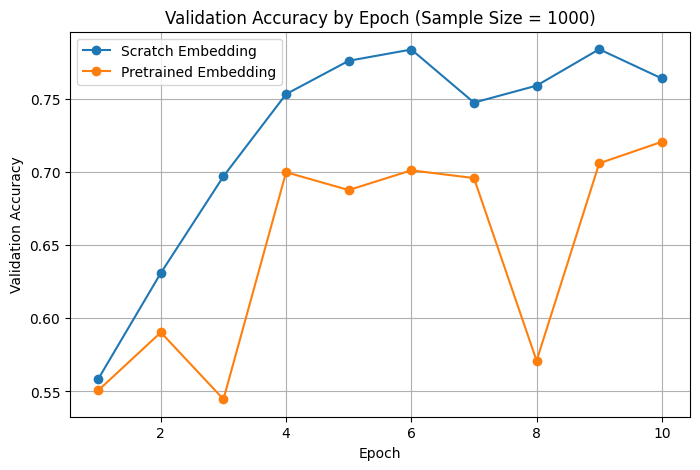


Winner at sample size 1000: Scratch Embedding
{'sample_size': 1000, 'scratch_best_epoch': np.int64(9), 'scratch_best_val_accuracy': np.float64(0.7839999794960022), 'pretrained_best_epoch': np.int64(10), 'pretrained_best_val_accuracy': np.float64(0.7207000255584717)}


In [26]:
result_1000 = run_models_for_sample_size(1000)
print(result_1000)


========== SAMPLE SIZE: 5000 ==========

Training SCRATCH embedding model...

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6548 - loss: 0.6088 - val_accuracy: 0.7906 - val_loss: 0.4656
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8290 - loss: 0.3999 - val_accuracy: 0.8465 - val_loss: 0.3670
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8750 - loss: 0.3023 - val_accuracy: 0.8493 - val_loss: 0.3756
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.9054 - loss: 0.2465 - val_accuracy: 0.8448 - val_loss: 0.3645
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9312 - loss: 0.1877 - val_accuracy: 0.8807 - val_loss: 0.3014
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9482 - loss: 0.1490 - val_accuracy: 0.9104 - val_loss: 0.2480
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9594 - loss: 0.1188 - val_accuracy: 0.8772 - val_loss: 0.3608
Epoch 8/10
157/157

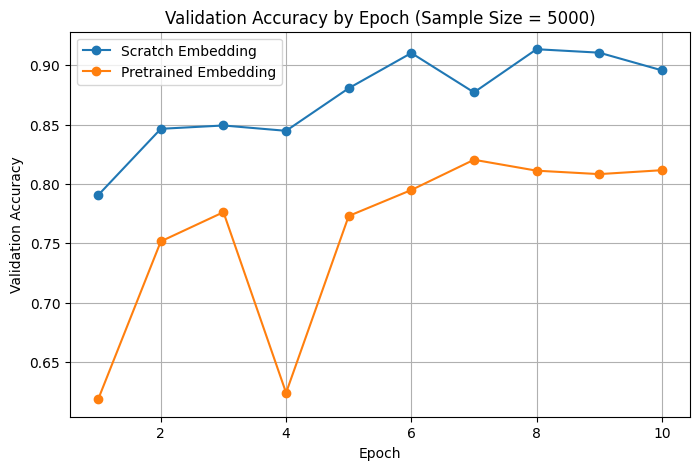


Winner at sample size 5000: Scratch Embedding
{'sample_size': 5000, 'scratch_best_epoch': np.int64(8), 'scratch_best_val_accuracy': np.float64(0.9136000275611877), 'pretrained_best_epoch': np.int64(7), 'pretrained_best_val_accuracy': np.float64(0.8203999996185303)}


In [27]:
result_5000 = run_models_for_sample_size(5000)
print(result_5000)


========== SAMPLE SIZE: 10000 ==========

Training SCRATCH embedding model...

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7330 - loss: 0.5186 - val_accuracy: 0.8749 - val_loss: 0.3237
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.8605 - loss: 0.3407 - val_accuracy: 0.9193 - val_loss: 0.2397
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.8898 - loss: 0.2776 - val_accuracy: 0.7340 - val_loss: 0.7351
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9148 - loss: 0.2256 - val_accuracy: 0.9255 - val_loss: 0.2002
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9301 - loss: 0.1921 - val_accuracy: 0.8763 - val_loss: 0.3143
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9401 - loss: 0.1718 - val_accuracy: 0.9664 - val_loss: 0.1196
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9515 - loss: 0.1426 - val_accuracy: 0.9773 - val_loss: 0.0788
Epoch 8/10
313/31

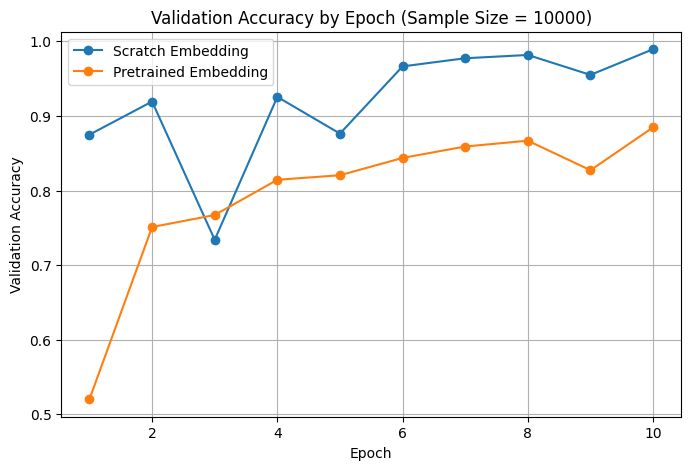


Winner at sample size 10000: Scratch Embedding
{'sample_size': 10000, 'scratch_best_epoch': np.int64(10), 'scratch_best_val_accuracy': np.float64(0.9894000291824341), 'pretrained_best_epoch': np.int64(10), 'pretrained_best_val_accuracy': np.float64(0.8847000002861023)}


In [28]:
result_10000 = run_models_for_sample_size(10000)
print(result_10000)


========== SAMPLE SIZE: 20000 ==========

Training SCRATCH embedding model...

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7767 - loss: 0.4628 - val_accuracy: 0.8831 - val_loss: 0.3082
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8752 - loss: 0.3065 - val_accuracy: 0.9206 - val_loss: 0.2146
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8993 - loss: 0.2567 - val_accuracy: 0.9049 - val_loss: 0.2455
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9158 - loss: 0.2181 - val_accuracy: 0.9399 - val_loss: 0.1779
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9260 - loss: 0.1958 - val_accuracy: 0.9557 - val_loss: 0.1391
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9384 - loss: 0.1706 - val_accuracy: 0.9593 - val_loss: 0.1316
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.9480 - loss: 0.1466 - val_accuracy: 0.9588 - val_loss: 0.1208
Epoch 8/10
625/6

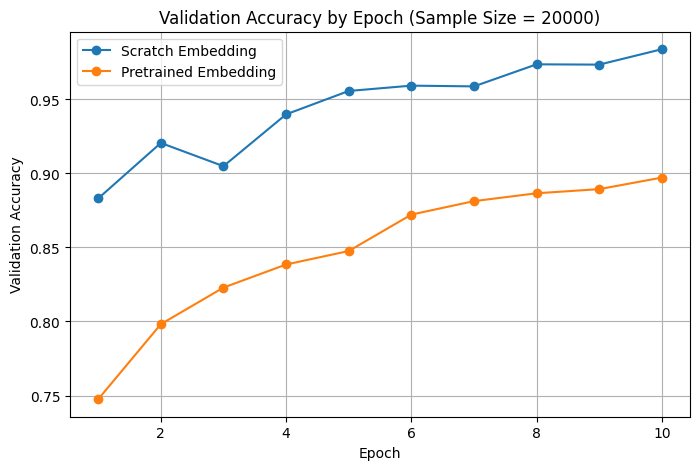


Winner at sample size 20000: Scratch Embedding
{'sample_size': 20000, 'scratch_best_epoch': np.int64(10), 'scratch_best_val_accuracy': np.float64(0.9839000105857849), 'pretrained_best_epoch': np.int64(10), 'pretrained_best_val_accuracy': np.float64(0.8971999883651733)}


In [30]:
result_20000 = run_models_for_sample_size(20000)
print(result_20000)

In [34]:
all_results = pd.DataFrame([
    result_100,
    result_200,
    result_500,
    result_1000,
    result_5000,
    result_10000,
    result_20000
])


========== FINAL COMPARISON TABLE ==========

   Sample Size  Scratch Accuracy  Pretrained Accuracy  Scratch Best Epoch  \
0          100            0.5673               0.5780                   9   
1          200            0.6155               0.5890                  10   
2          500            0.7450               0.6965                   8   
3         1000            0.7840               0.7207                   9   
4         5000            0.9136               0.8204                   8   
5        10000            0.9894               0.8847                  10   
6        20000            0.9839               0.8972                  10   

   Pretrained Best Epoch      Winner  
0                     10  Pretrained  
1                     10     Scratch  
2                      8     Scratch  
3                     10     Scratch  
4                      7     Scratch  
5                     10     Scratch  
6                     10     Scratch  

========== BEST VALUES 

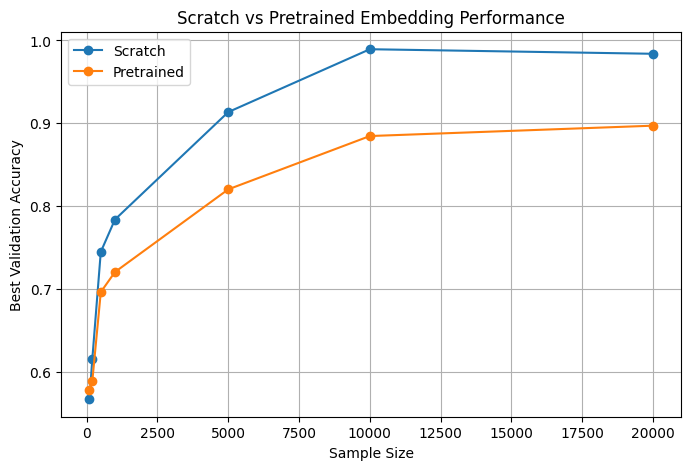

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

all_results = all_results.rename(columns={
    "sample_size": "Sample Size",
    "scratch_best_val_accuracy": "Scratch Accuracy",
    "pretrained_best_val_accuracy": "Pretrained Accuracy",
    "scratch_best_epoch": "Scratch Best Epoch",
    "pretrained_best_epoch": "Pretrained Best Epoch"
})

all_results = all_results.sort_values(by="Sample Size")

def winner(row):
    if row["Scratch Accuracy"] > row["Pretrained Accuracy"]:
        return "Scratch"
    elif row["Pretrained Accuracy"] > row["Scratch Accuracy"]:
        return "Pretrained"
    else:
        return "Tie"

all_results["Winner"] = all_results.apply(winner, axis=1)

print("\n========== FINAL COMPARISON TABLE ==========\n")
print(all_results[[
    "Sample Size",
    "Scratch Accuracy",
    "Pretrained Accuracy",
    "Scratch Best Epoch",
    "Pretrained Best Epoch",
    "Winner"
]])

print("\n========== BEST VALUES SUMMARY ==========\n")
for _, row in all_results.iterrows():
    print(f"Sample Size: {row['Sample Size']}")
    print(f"  Scratch     -> Acc: {row['Scratch Accuracy']:.4f}, Epoch: {row['Scratch Best Epoch']}")
    print(f"  Pretrained  -> Acc: {row['Pretrained Accuracy']:.4f}, Epoch: {row['Pretrained Best Epoch']}")
    print(f"  Winner: {row['Winner']}")
    print("-" * 50)

plt.figure(figsize=(8,5))

plt.plot(all_results["Sample Size"], all_results["Scratch Accuracy"], marker='o', label="Scratch")
plt.plot(all_results["Sample Size"], all_results["Pretrained Accuracy"], marker='o', label="Pretrained")

plt.xlabel("Sample Size")
plt.ylabel("Best Validation Accuracy")
plt.title("Scratch vs Pretrained Embedding Performance")
plt.legend()
plt.grid(True)

plt.show()

In [41]:
import pandas as pd

rows = []

# Loop through your results DataFrame
for i, row in all_results.iterrows():

    sample = row["Sample Size"]


    rows.append({
        "S.No": len(rows) + 1,
        "Training Samples": sample,
        "Model Type": "Embedding (Scratch)",
        "Validation Accuracy": round(row["Scratch Accuracy"], 4),
        "Performance": (
            "Very Low" if row["Scratch Accuracy"] < 0.55 else
            "Moderate" if row["Scratch Accuracy"] < 0.70 else
            "Strong" if row["Scratch Accuracy"] < 0.78 else
            "Very Strong"
        )
    })


    rows.append({
        "S.No": len(rows) + 1,
        "Training Samples": sample,
        "Model Type": "Pretrained GloVe",
        "Validation Accuracy": round(row["Pretrained Accuracy"], 4),
        "Performance": (
            "Better in Low Data" if sample == 100 else
            "Stable but Limited" if row["Pretrained Accuracy"] < 0.65 else
            "Moderate"
        )
    })


final_table = pd.DataFrame(rows)


print("\n========== FINAL FORMATTED TABLE ==========\n")
print(final_table.to_string(index=False))


========== FINAL FORMATTED TABLE ==========

 S.No  Training Samples          Model Type  Validation Accuracy        Performance
    1               100 Embedding (Scratch)               0.5673           Moderate
    2               100    Pretrained GloVe               0.5780 Better in Low Data
    3               200 Embedding (Scratch)               0.6155           Moderate
    4               200    Pretrained GloVe               0.5890 Stable but Limited
    5               500 Embedding (Scratch)               0.7450             Strong
    6               500    Pretrained GloVe               0.6965           Moderate
    7              1000 Embedding (Scratch)               0.7840        Very Strong
    8              1000    Pretrained GloVe               0.7207           Moderate
    9              5000 Embedding (Scratch)               0.9136        Very Strong
   10              5000    Pretrained GloVe               0.8204           Moderate
   11             10000 Embedd